Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import pyro

smoke_test = False


In [ ]:
def construct_mudata(data_dir="."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs["library_size"] = rna_adata.X.sum(axis=1)
    rna_adata.varm["element_tested"] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm["element_targeted"] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    assert (rna_adata.varm["element_tested"].columns == grna_adata.varm["element_targeted"].columns).all()
    mdata = md.MuData({"rna": rna_adata, "grna": grna_adata})
    mdata.write_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
    return mdata


force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
data_dir = "../../../../Data/gasperini_pilot"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = construct_mudata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))
mdata

MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [ ]:
# mdata['grna'].varm['gene_targeted']
# mdata['rna'].varm['gene_tested']
mdata["grna"].varm["element_targeted"]


Element,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
guides = mdata["grna"].var_names
selected_guides = list(guides)
# selected_guides = list(guides[guides.str.contains(r"TSS|random|scrambled", regex=True)])
if smoke_test:
    selected_guides = selected_guides[:20] + selected_guides[-10:]
    print("guides", selected_guides)

selected_elements = list({guide.split("|")[0] for guide in selected_guides if "_TSS" in guide})
element_subset = mdata["grna"].varm["element_targeted"][selected_elements].copy()

grna_subset = mdata["grna"]
grna_subset.varm["element_targeted"] = element_subset

grna_subset = mdata["grna"][:, selected_guides]
genes = list(sorted({e.split("_")[0] for e in selected_elements if "_TSS" in e}))
subset_genes = [g for g in genes if g in mdata["rna"].var_names]
subset_genes = [subset_genes[1]] # DANGER SINGLE GENE ONLY
print(subset_genes)

if smoke_test:
    print("elements", selected_elements)
    print("genes", subset_genes)
assert grna_subset.varm["element_targeted"].shape == (len(selected_guides), len(selected_elements))


['ACTB', 'ACTG1', 'ACYP1', 'ADIPOR1', 'ALDH1A2', 'APEX1', 'APLP2', 'ARF6', 'ARID1A', 'ARL4A', 'ARL5A', 'ARV1', 'ASAH1', 'ATP6V1F', 'AZIN1', 'BANF1', 'BCAP29', 'BEX4', 'BLVRB', 'BRI3', 'BRIX1', 'BROX', 'BTF3', 'BTF3L4', 'BUB3', 'C16orf91', 'C1D', 'C1orf52', 'CALM3', 'CAP1', 'CAPZA2', 'CCDC58', 'CCDC71L', 'CCDC86', 'CCND2', 'CCNDBP1', 'CCT5', 'CD46', 'CD47', 'CEBPB', 'CENPK', 'CENPW', 'CERS2', 'CHCHD10', 'CHCHD3', 'CHMP1B', 'CHPT1', 'CHRAC1', 'CITED2', 'CKB', 'CMPK1', 'CNBP', 'CNIH4', 'COA1', 'COA3', 'COMMD3', 'COMT', 'COPRS', 'COPS5', 'COX4I1', 'COX6A1', 'CRIPT', 'CRLS1', 'CSNK1A1', 'CSTB', 'CTCFL', 'CUTA', 'CWC15', 'CYB5B', 'DAZAP2', 'DCTPP1', 'DDX3X', 'DECR1', 'DHX29', 'DIMT1', 'DLK1', 'DNAJB6', 'DYNC1I2', 'DYNLT1', 'EBPL', 'EEF1A1', 'EEF2', 'EIF2S1', 'EIF2S2', 'EIF3A', 'EIF3D', 'EIF3G', 'EIF3J', 'EIF4A3', 'EIF4E', 'EIF4EBP1', 'EIF4G2', 'EIF4H', 'ELAVL1', 'ELOVL5', 'EPB41', 'EWSR1', 'EXOSC7', 'FAM133B', 'FAM204A', 'FAM83A', 'FBL', 'FECH', 'FH', 'FKBP1A', 'FKBP2', 'GADD45A', 'GAL', 'GA

In [ ]:
grna_subset.varm["element_targeted"].shape


(3115, 381)

In [ ]:
rna_subset = mdata["rna"]
rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][selected_elements].copy()
rna_subset = rna_subset[:, subset_genes]
mdata_subset = md.MuData({"rna": rna_subset.copy(), "grna": grna_subset.copy()})
assert (mdata_subset['rna'].varm['element_tested'].columns == mdata_subset['grna'].varm['element_targeted'].columns).all()
mdata_subset


MuData object with n_obs × n_vars = 47964 × 3488
  2 modalities
    rna:	47964 x 373
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [ ]:
perturbvi.PERTURBVI.setup_mudata(
    mdata_subset,
    batch_key="bath_number",
    size_factor_key="library_size",
    var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbvi.PERTURBVI(mdata_subset)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': 'element_tested',
│   'perturb_by_element_key': 'element_targeted',
│   'perturbation_layer': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'},
│   'size_factor_key': 'library_size'
}

      Summary Statistics       
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Summary Stat Key   ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_batch       │   6   │
│       n_cells       │ 47964 │
│   n_perturbations   │ 3115  │
│ n_targeted_elements │  381  │
│  n_tested_elements  │  381  │
│       n_vars        │  373  │
└─────────────────────┴───────┘

                          Data Registry                           
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Registry Key    ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X         │             adata.mod['rna'].X             │
│       batch       │    adata.mod['rna'].obs['_scvi_batch']     │
│       ind_x       │       adata.mod['rna'].obs['_ind_x']       │
│ observed_lib_size │    adata.mod['rna'].obs['library_size']    │
│   perturbations   │            adata.mod['grna'].X             │
│ targeted_elements │ adata.mod['grna'].varm['element_targeted'] │
│  tested_elements  │  adata.mod['rna'].varm['element_tested']   │
└───────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

In [ ]:
mdata_subset['rna'].varm['element_tested']
mdata_subset['grna'].varm['element_targeted']


Element,APEX1_TSS,TIMM10_TSS,FAM96A_TSS,FAM133B_TSS,MRPS18C_TSS,RTN3_TSS,SEC11A_TSS,WSB1_TSS,TMEM59_TSS,TOMM7_TSS,...,KRT18_TSS,GYPC_TSS,FAM83A_TSS,MBOAT2_TSS,NDUFB2_TSS,KCNH2_TSS,PDIA4_TSS,TUBB_TSS,VDAC3_TSS,MTRNR2L8_TSS
ACTB_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# burn-in
model.train(10, lr=0.1, batch_size=4096)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 3/10:  20%|██        | 2/10 [00:14<00:56,  7.03s/it, v_num=1, elbo_train=7.35e+7]

/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [ ]:
# fine tune
max_epochs = 50
model.train(max_epochs=max_epochs, lr=0.01, batch_size=None)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower 

Epoch 17/50:  32%|███▏      | 16/50 [00:03<00:06,  5.31it/s, v_num=1, elbo_train=1.67e+9]

In [ ]:
%load_ext autoreload
%autoreload 2
from matplotlib.scale import scale_factory
from pyparsing import col
from scipy.stats import norm
from torch import sign

lfc_threshold = 0.05 # ~ at least 5% knockdown
# lfc_threshold = 0 # nonzero knockdown
# gene_index=45

scale_factor = 0.1
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril'] * scale_factor
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.cdf(lfc_threshold, loc=-perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

significant_results = (
    pd.DataFrame(data=perturb_z_scores, columns=subset_genes, index=selected_guides)
    .melt(var_name="gene", ignore_index=False)
    .reset_index(names="guide")
    .sort_values("value")
    .assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'])
)
# significant_results['guide'].str.split("_", expand=True)[0]
significant_results

,guide,gene,value,is_target
2,ACTG1_TSS|1,ACTG1,-8.949637,True
3,ACTG1_TSS|2,ACTG1,-3.489792,True
1620,chr1:227556757-227556780|2,ACTG1,-2.002806,False
2940,chrX:12973885-12973908|2,ACTG1,-1.737249,False
242,GPN3_TSS|1,ACTG1,-1.581979,False
...,...,...,...,...
173,EEF2_TSS|2,ACTG1,2.133982,False
83,CCT5_TSS|2,ACTG1,2.442892,False
895,chr11:33966182-33966205|1,ACTG1,2.630597,False
1,ACTB_TSS|2,ACTG1,6.262060,False


<Axes: xlabel='value', ylabel='Percent'>

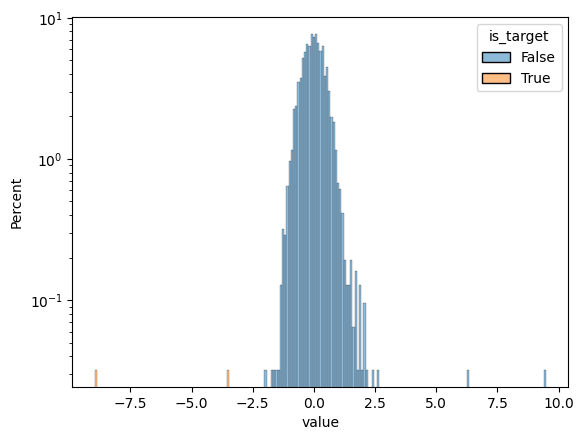

In [ ]:
sns.histplot(significant_results, hue='is_target', x='value', stat="percent", log_scale=[False,True])
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


In [ ]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


log_var_mean.mu torch.Size([1])
tensor([-3.8103], requires_grad=True)
log_var_disp.mu torch.Size([1])
tensor([-1.0769], requires_grad=True)
batch_effect.mu torch.Size([6, 1])
batch_effect.sigma torch.Size([6, 1])
log_var_mean.sigma torch.Size([1])
tensor([1.3636], grad_fn=<AddBackward0>)
log_var_disp.sigma torch.Size([1])
tensor([1.5755], grad_fn=<AddBackward0>)
perturb_mean_lfc.mu torch.Size([3115, 1])
perturb_disp_lfc.mu torch.Size([3115, 1])
perturb_lfc.scale_tril torch.Size([3115, 1, 2, 2])
